In [1]:
# ============================================================
# CELL 1: Data Consolidation
# ============================================================
"""
Consolidate individual run folders into master DataFrames.

Reads data from: ferme_data/Run_X/ folders
Creates: 01_all_offline_samples.csv, 02_bioreactor_online_sampled.csv, 03_feed_logs.csv
"""

import sys
import os
import pandas as pd
import numpy as np

sys.path.append('.')

from config_ferm import CONSOLIDATION_CONFIG
from utils import consolidate_files

print("="*70)
print("DATA CONSOLIDATION")
print("="*70)

# Consolidate all files using universal function + config
consolidated_data, run_folders = consolidate_files(CONSOLIDATION_CONFIG)

# Count total files
total_files = len(run_folders) * len(CONSOLIDATION_CONFIG['files'])

print(f"\nFound {len(run_folders)} run folders with {total_files} total files")

# Dynamic file mapping based on config
file_mapping = {
    'offline': '01_all_offline_samples.csv',
    'bioreactor': '02_bioreactor_online_sampled.csv',
    'feed': '03_feed_logs.csv'
}

# Save and print consolidated files dynamically
print(f"\nConsolidation complete:")

for key, filename in file_mapping.items():
    df = consolidated_data.get(key, pd.DataFrame())
    if not df.empty:
        df.to_csv(filename, index=False)
        # Format the display name (capitalize and add spaces)
        display_name = key.replace('_', ' ').capitalize()
        print(f"  {display_name:16s}: {len(df):4d} rows → {filename}")

print("\nReady for quality assessment")

DATA CONSOLIDATION

Found 6 run folders with 18 total files

Consolidation complete:
  Offline         :   68 rows → 01_all_offline_samples.csv
  Bioreactor      : 1455 rows → 02_bioreactor_online_sampled.csv
  Feed            :   60 rows → 03_feed_logs.csv

Ready for quality assessment


In [2]:
# ============================================================
# CELL 2: Quality Assessment
# ============================================================
"""
Perform comprehensive quality checks on consolidated data.

Checks performed:
1. Column consistency across runs
2. Missing values
3. Duplicate rows
4. Data types
5. Sampling consistency
6. Value ranges
7. Time continuity (bioreactor logs)

Output: data_quality_report.txt
"""

from config_ferm import QUALITY_CONFIG, CONSOLIDATION_CONFIG
from utils import (
    check_missing_values,
    check_duplicates,
    check_data_types,
    check_sampling_consistency,
    check_value_ranges,
    check_time_continuity,
    check_column_consistency,
    generate_report
)

print("="*70)
print("QUALITY ASSESSMENT")
print("="*70)

# Load consolidated data
raw_offline = pd.read_csv('01_all_offline_samples.csv')
raw_bioreactor = pd.read_csv('02_bioreactor_online_sampled.csv')
raw_feed = pd.read_csv('03_feed_logs.csv')

print(f"\nDatasets loaded: {len(raw_offline)} offline, {len(raw_bioreactor)} bioreactor, {len(raw_feed)} feed records")

# Get run folders for report
base_folder = CONSOLIDATION_CONFIG['base_folder']
run_folders = [f for f in os.listdir(base_folder) 
               if os.path.isdir(os.path.join(base_folder, f)) 
               and f.startswith(CONSOLIDATION_CONFIG['run_folder_prefix'])]

all_checks = []

print(f"\nExecuting {7} quality checks...")

# ============================================================================
# RUN ALL CHECKS WITH BRIEF OUTPUT
# ============================================================================

# Check 1: Column Consistency
if QUALITY_CONFIG.get('check_column_consistency', False):
    result = check_column_consistency(
        raw_offline,
        QUALITY_CONFIG['group_by_column'],
        '01_all_offline_samples.csv'
    )
    all_checks.append(result)
    
    if result['status'] == 'FAIL':
        for issue in result['details']:
            if 'extra_columns' in issue:
                print(f"  Column Consistency: FAIL - {issue['group']} has extra column(s): {', '.join(issue['extra_columns'])}")

# Check 2: Missing Values
result = check_missing_values(raw_offline, '01_all_offline_samples.csv')
all_checks.append(result)

if result['status'] == 'FAIL':
    total_missing = sum(info['count'] for info in result['details'].values())
    num_cols = len(result['details'])
    print(f"  Missing Values: FAIL - {total_missing} missing values in {num_cols} column(s)")

# Check 3: Duplicates
result = check_duplicates(raw_offline, '01_all_offline_samples.csv')
all_checks.append(result)

if result['status'] == 'FAIL':
    print(f"  Duplicate Rows: FAIL - {result['details']}")

# Check 4: Data Types
result = check_data_types(
    raw_offline,
    '01_all_offline_samples.csv',
    QUALITY_CONFIG['expected_types']
)
all_checks.append(result)

# Check 5: Sampling Consistency
result = check_sampling_consistency(
    raw_offline,
    QUALITY_CONFIG['group_by_column']
)
all_checks.append(result)

if result['status'] == 'FAIL':
    counts = list(result['breakdown'].values())
    print(f"  Sampling Consistency: FAIL - Sample counts vary {min(counts)}-{max(counts)} across runs")

# Check 6: Value Ranges
result = check_value_ranges(
    raw_offline,
    '01_all_offline_samples.csv',
    QUALITY_CONFIG['value_ranges']
)
all_checks.append(result)

if result['status'] == 'FAIL':
    num_issues = len(result['details'])
    print(f"  Value Ranges: FAIL - {num_issues} variable(s) outside expected ranges")

# Check 7: Time Continuity (Bioreactor)
result = check_time_continuity(
    raw_bioreactor,
    QUALITY_CONFIG['time_column'],
    QUALITY_CONFIG['expected_interval'],
    QUALITY_CONFIG['tolerance']
)
all_checks.append(result)

if result['status'] == 'FAIL':
    num_gaps = len(result['details'])
    print(f"  Time Continuity: FAIL - {num_gaps} time gap(s) detected in bioreactor logs")

# ============================================================================
# GENERATE DETAILED REPORT
# ============================================================================
report_path = generate_report(all_checks, run_folders, CONSOLIDATION_CONFIG)

passed = sum(1 for c in all_checks if c['status'] == 'PASS')
failed = sum(1 for c in all_checks if c['status'] == 'FAIL')

# ============================================================================
# PRINT SUMMARY
# ============================================================================
print(f"\n{'='*70}")
print("RESULTS SUMMARY")
print("="*70)

# Print each check result in table format
for i, check in enumerate(all_checks, 1):
    status_symbol = "✓" if check['status'] == "PASS" else "✗"
    status_text = "PASS" if check['status'] == "PASS" else "FAIL"
    print(f"{i}. {check['check']:30s} [{status_symbol}] {status_text}")

print(f"\n{'='*70}")
print(f"Quality Score: {passed}/{len(all_checks)} checks passed")
print(f"Detailed report: {report_path}")

if failed > 0:
    print(f"\nStatus: Issues detected - review report and proceed to Cell 3 for cleaning")
else:
    print(f"\nStatus: All checks passed - data ready for analysis")

print("="*70)

QUALITY ASSESSMENT

Datasets loaded: 68 offline, 1455 bioreactor, 60 feed records

Executing 7 quality checks...
  Column Consistency: FAIL - run3_KPB1 has extra column(s): Glucose_mM
  Missing Values: FAIL - 71 missing values in 2 column(s)
  Duplicate Rows: FAIL - 2 duplicate rows found
  Sampling Consistency: FAIL - Sample counts vary 11-13 across runs

RESULTS SUMMARY
1. Column Consistency             [✗] FAIL
2. Missing Values                 [✗] FAIL
3. Duplicate Rows                 [✗] FAIL
4. Data Types                     [✓] PASS
5. Sampling Consistency           [✗] FAIL
6. Value Ranges                   [✓] PASS
7. Time Continuity                [✓] PASS

Quality Score: 3/7 checks passed
Detailed report: data_quality_report.txt

Status: Issues detected - review report and proceed to Cell 3 for cleaning


In [3]:
# ============================================================
# CELL 3: Data Cleaning
# ============================================================
"""
Clean data based on quality assessment findings.

Operations:
- Remove duplicates and impossible values
- Apply experiment-specific fixes
- Extract metadata from run IDs
- Generate cleaned datasets

Output: ferm_data_cleaned/ folder
"""

from config_ferm import CLEANING_CONFIG, extract_metadata_from_run_id
from utils import remove_duplicates, sort_dataframe
from datetime import datetime

print("="*70)
print("DATA CLEANING")
print("="*70)

# Load consolidated data
df_offline = pd.read_csv('01_all_offline_samples.csv')
df_bioreactor = pd.read_csv('02_bioreactor_online_sampled.csv')
df_feed = pd.read_csv('03_feed_logs.csv')

print(f"\nInput: {len(df_offline)} offline, {len(df_bioreactor)} bioreactor, {len(df_feed)} feed records")

cleaning_log = []

# ============================================================================
# SECTION A: UNIVERSAL OPERATIONS
# ============================================================================
print(f"\nA. Universal Operations")

# A1: Remove duplicates
df_offline, dup_offline = remove_duplicates(df_offline)
df_bioreactor, dup_bioreactor = remove_duplicates(df_bioreactor)
df_feed, dup_feed = remove_duplicates(df_feed)

total_dup = dup_offline + dup_bioreactor + dup_feed
if total_dup > 0:
    cleaning_log.append(f"Removed {total_dup} duplicates")
    print(f"  • Removed {total_dup} duplicate rows")

# A2: Replace biologically impossible values with NaN
impossible_fixes = []

if (df_offline['Biomass_gL'] < 0).any():
    count = (df_offline['Biomass_gL'] < 0).sum()
    df_offline.loc[df_offline['Biomass_gL'] < 0, 'Biomass_gL'] = np.nan
    impossible_fixes.append(f"Biomass_gL: {count} negative → NaN")

if (df_offline['Viability_%'] > 100).any():
    count = (df_offline['Viability_%'] > 100).sum()
    df_offline.loc[df_offline['Viability_%'] > 100, 'Viability_%'] = np.nan
    impossible_fixes.append(f"Viability_%: {count} > 100% → NaN")

if (df_offline['Viability_%'] < 0).any():
    count = (df_offline['Viability_%'] < 0).sum()
    df_offline.loc[df_offline['Viability_%'] < 0, 'Viability_%'] = np.nan
    impossible_fixes.append(f"Viability_%: {count} negative → NaN")

if impossible_fixes:
    for fix in impossible_fixes:
        cleaning_log.append(f"Corrected impossible values: {fix}")
    print(f"  • Corrected {len(impossible_fixes)} impossible value types")

# A3: Sort data
df_offline = sort_dataframe(df_offline, CLEANING_CONFIG['sort_by'])
df_bioreactor = sort_dataframe(df_bioreactor, ['Run_ID', 'Timestamp'])
df_feed = sort_dataframe(df_feed, ['Run_ID', 'Time_h'])
cleaning_log.append("Sorted datasets chronologically")
print(f"  • Sorted all datasets chronologically")

# ============================================================================
# SECTION B: EXPERIMENT-SPECIFIC FIXES
# ============================================================================
print(f"\nB. Experiment-Specific Fixes")

fix_count = 0

# Fix B1: Glucose unit conversion
if 'Glucose_mM' in df_offline.columns:
    affected_runs = df_offline[df_offline['Glucose_mM'].notna()]['Run_ID'].unique()
    
    if 'Glucose_gL' in df_offline.columns:
        df_offline['Glucose_gL'] = df_offline['Glucose_gL'].fillna(
            df_offline['Glucose_mM'] * 180 / 1000
        )
    else:
        df_offline['Glucose_gL'] = df_offline['Glucose_mM'] * 180 / 1000
    
    df_offline = df_offline.drop('Glucose_mM', axis=1)
    
    cleaning_log.append(f"Converted Glucose_mM → Glucose_gL for {', '.join(affected_runs)}")
    print(f"  • Converted glucose units (mM → g/L) for {len(affected_runs)} run(s)")
    fix_count += 1

if fix_count == 0:
    print(f"  • No experiment-specific fixes required")

# ============================================================================
# SECTION C: METADATA EXTRACTION
# ============================================================================
print(f"\nC. Metadata Extraction")

if CLEANING_CONFIG['metadata_extraction']['enabled']:
    fields = CLEANING_CONFIG['metadata_extraction']['fields']
    
    df_offline[fields] = df_offline['Run_ID'].apply(
        lambda x: pd.Series(extract_metadata_from_run_id(x))
    )
    df_bioreactor[fields] = df_bioreactor['Run_ID'].apply(
        lambda x: pd.Series(extract_metadata_from_run_id(x))
    )
    df_feed[fields] = df_feed['Run_ID'].apply(
        lambda x: pd.Series(extract_metadata_from_run_id(x))
    )
    
    cleaning_log.append(f"Extracted metadata: {', '.join(fields)}")
    print(f"  • Extracted {len(fields)} experimental factors: {', '.join(fields)}")

# ============================================================================
# SECTION D: METADATA SUMMARY
# ============================================================================
print(f"\nD. Metadata Summary")

metadata = df_offline.groupby(['Run_ID', 'Strain', 'Methanol_Strategy']).agg(
    Duration_h=('Time_h', 'max'),
    Samples_Collected=('Time_h', 'count'),
    Final_Biomass_gL=('Biomass_gL', 'last'),
    Final_Protein_mgL=('Protein_mgL', 'last'),
    Final_Viability_pct=('Viability_%', 'last')
).reset_index()

expected_samples = df_offline.groupby('Run_ID').size().max()
metadata['Complete_Sampling'] = metadata['Samples_Collected'] == expected_samples

complete = metadata['Complete_Sampling'].sum()
incomplete = (~metadata['Complete_Sampling']).sum()

print(f"  • {len(metadata)} runs processed: {complete} complete, {incomplete} incomplete")

if incomplete > 0:
    incomplete_runs = metadata[~metadata['Complete_Sampling']]['Run_ID'].tolist()
    print(f"    Incomplete runs: {', '.join(incomplete_runs)}")

# ============================================================================
# SECTION E: SAVE CLEANED DATA
# ============================================================================
print(f"\nE. Save Cleaned Data")

output_folder = CLEANING_CONFIG['output_folder']
os.makedirs(output_folder, exist_ok=True)

output_files = {
    'master_offline_samples.csv': df_offline,
    'master_bioreactor_log.csv': df_bioreactor,
    'master_feed_log.csv': df_feed,
    'metadata.csv': metadata
}

for filename, df in output_files.items():
    filepath = os.path.join(output_folder, filename)
    df.to_csv(filepath, index=False)

print(f"  • Saved {len(output_files)} files to {output_folder}/")
print(f"    Output: {len(df_offline)} offline, {len(df_bioreactor)} bioreactor, {len(df_feed)} feed, {len(metadata)} metadata")

# Save cleaning log
os.makedirs('outputs', exist_ok=True)
log_path = 'outputs/cleaning_log.txt'

with open(log_path, 'w', encoding='utf-8') as f:
    f.write("DATA CLEANING LOG\n")
    f.write("="*70 + "\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
    f.write("ACTIONS PERFORMED:\n")
    f.write("-"*70 + "\n")
    for i, action in enumerate(cleaning_log, 1):
        f.write(f"{i}. {action}\n")
    f.write("\n" + "="*70 + "\n")

print(f"  • Cleaning log: {log_path}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print(f"\n{'='*70}")
print(f"CLEANING COMPLETE: {len(cleaning_log)} operations performed")
print(f"Ready for exploratory data analysis")
print("="*70)


DATA CLEANING

Input: 68 offline, 1455 bioreactor, 60 feed records

A. Universal Operations
  • Removed 5 duplicate rows
  • Sorted all datasets chronologically

B. Experiment-Specific Fixes
  • Converted glucose units (mM → g/L) for 1 run(s)

C. Metadata Extraction
  • Extracted 2 experimental factors: Strain, Methanol_Strategy

D. Metadata Summary
  • 6 runs processed: 6 complete, 0 incomplete

E. Save Cleaned Data
  • Saved 4 files to ferm_data_cleaned/
    Output: 66 offline, 1452 bioreactor, 60 feed, 6 metadata
  • Cleaning log: outputs/cleaning_log.txt

CLEANING COMPLETE: 4 operations performed
Ready for exploratory data analysis


In [4]:
# ============================================================
# CELL 4: Setup and Load Cleaned Data
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

# Load cleaned data
data_folder = 'ferm_data_cleaned'

master_offline = pd.read_csv(f'{data_folder}/master_offline_samples.csv')
master_bioreactor = pd.read_csv(f'{data_folder}/master_bioreactor_log.csv')
master_feed = pd.read_csv(f'{data_folder}/master_feed_log.csv')
metadata = pd.read_csv(f'{data_folder}/metadata.csv')

print(f"\nDatasets loaded:")
print(f"  Offline samples:  {master_offline.shape[0]:4d} rows x {master_offline.shape[1]:2d} cols")
print(f"  Bioreactor logs:  {master_bioreactor.shape[0]:4d} rows x {master_bioreactor.shape[1]:2d} cols")
print(f"  Feed logs:        {master_feed.shape[0]:4d} rows x {master_feed.shape[1]:2d} cols")
print(f"  Metadata:         {metadata.shape[0]:4d} runs")

print(f"\nExperimental design:")
print(f"  Strains: {', '.join(metadata['Strain'].unique())}")
print(f"  Strategies: {', '.join(metadata['Methanol_Strategy'].unique())}")
print(f"  Duration: 0-{master_offline['Time_h'].max():.0f} hours")

print(f"\nPerformance ranges:")
print(f"  Biomass: {metadata['Final_Biomass_gL'].min():.1f}-{metadata['Final_Biomass_gL'].max():.1f} g/L")
print(f"  Protein: {metadata['Final_Protein_mgL'].min():.0f}-{metadata['Final_Protein_mgL'].max():.0f} mg/L")
print(f"  Viability: {metadata['Final_Viability_pct'].min():.1f}-{metadata['Final_Viability_pct'].max():.1f}%")

# Create output folders
os.makedirs('outputs/figures', exist_ok=True)

print("\nReady for exploratory analysis")

EXPLORATORY DATA ANALYSIS

Datasets loaded:
  Offline samples:    66 rows x  9 cols
  Bioreactor logs:  1452 rows x  8 cols
  Feed logs:          60 rows x  7 cols
  Metadata:            6 runs

Experimental design:
  Strains: KP-B1, KP-B2
  Strategies: Pulsed, Continuous, Ramped
  Duration: 0-120 hours

Performance ranges:
  Biomass: 18.5-24.0 g/L
  Protein: 28793-33180 mg/L
  Viability: 90.4-93.4%

Ready for exploratory analysis



TIME-SERIES ANALYSIS


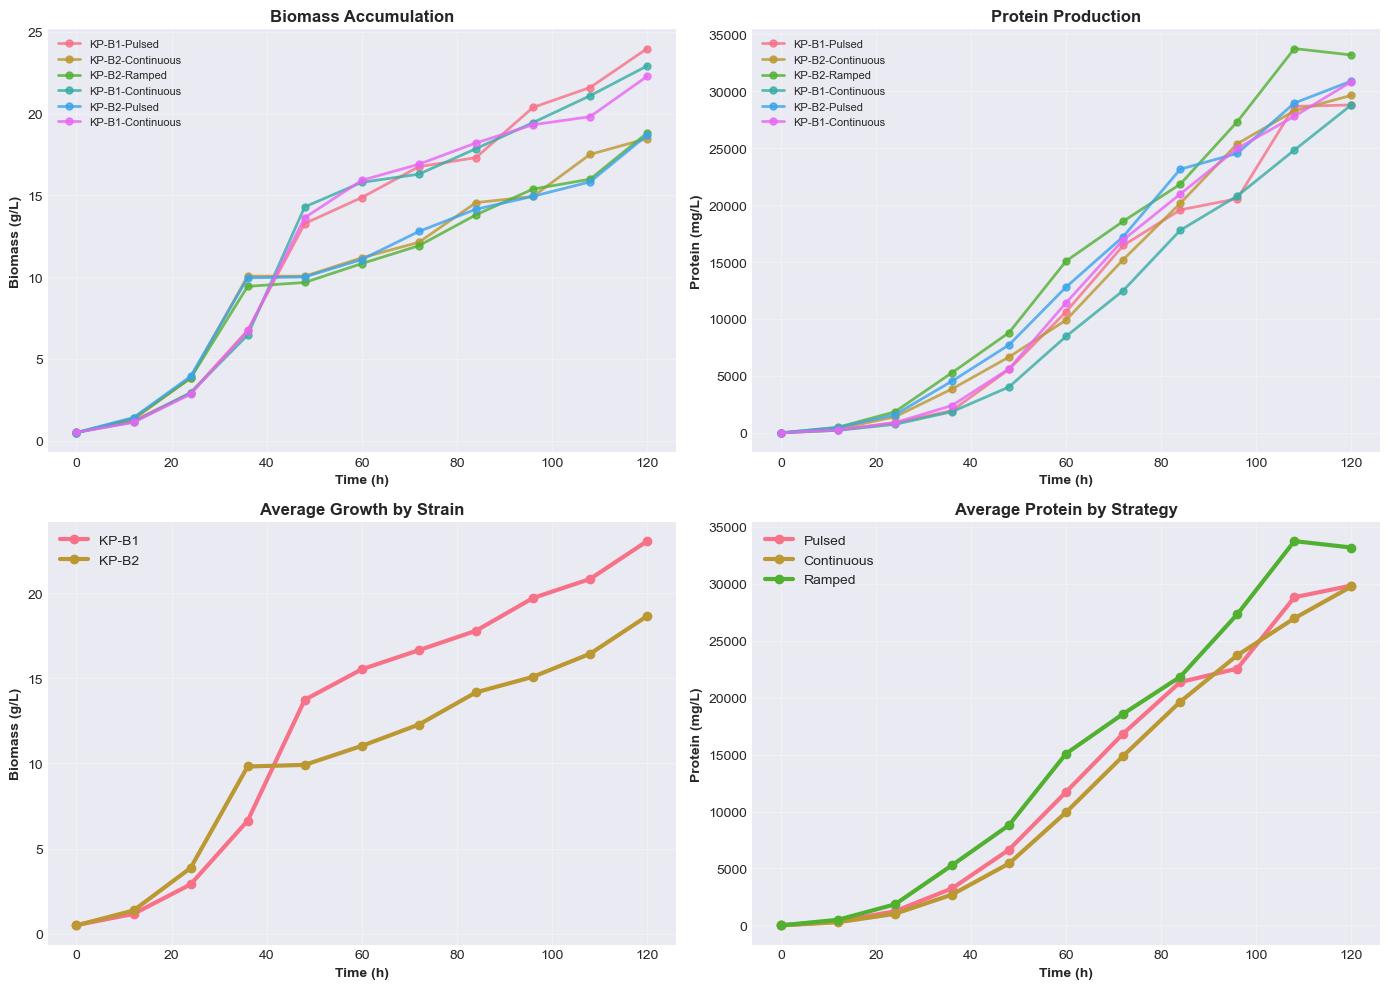

Figure saved: 01_growth_and_protein_profiles.png


In [5]:
# ============================================================
# CELL 5: Growth and Protein Production Profiles
# ============================================================
print("\n" + "="*70)
print("TIME-SERIES ANALYSIS")
print("="*70)

# Create combined figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Biomass growth - all runs
ax = axes[0, 0]
for run_id in master_offline['Run_ID'].unique():
    run_data = master_offline[master_offline['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    ax.plot(run_data['Time_h'], run_data['Biomass_gL'], 
            marker='o', linewidth=2, markersize=5, alpha=0.8,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Biomass (g/L)', fontweight='bold')
ax.set_title('Biomass Accumulation', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# Panel 2: Protein production - all runs
ax = axes[0, 1]
for run_id in master_offline['Run_ID'].unique():
    run_data = master_offline[master_offline['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    ax.plot(run_data['Time_h'], run_data['Protein_mgL'], 
            marker='o', linewidth=2, markersize=5, alpha=0.8,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Protein (mg/L)', fontweight='bold')
ax.set_title('Protein Production', fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3)

# Panel 3: Average growth by strain
ax = axes[1, 0]
for strain in master_offline['Strain'].unique():
    strain_data = master_offline[master_offline['Strain'] == strain]
    avg_growth = strain_data.groupby('Time_h')['Biomass_gL'].mean()
    ax.plot(avg_growth.index, avg_growth.values, 
            marker='o', linewidth=3, markersize=6, label=strain)

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Biomass (g/L)', fontweight='bold')
ax.set_title('Average Growth by Strain', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Panel 4: Average protein by strategy
ax = axes[1, 1]
for strategy in master_offline['Methanol_Strategy'].unique():
    strategy_data = master_offline[master_offline['Methanol_Strategy'] == strategy]
    avg_protein = strategy_data.groupby('Time_h')['Protein_mgL'].mean()
    ax.plot(avg_protein.index, avg_protein.values, 
            marker='o', linewidth=3, markersize=6, label=strategy)

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Protein (mg/L)', fontweight='bold')
ax.set_title('Average Protein by Strategy', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/figures/01_growth_and_protein_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 01_growth_and_protein_profiles.png")


BIOREACTOR PROCESS PARAMETERS


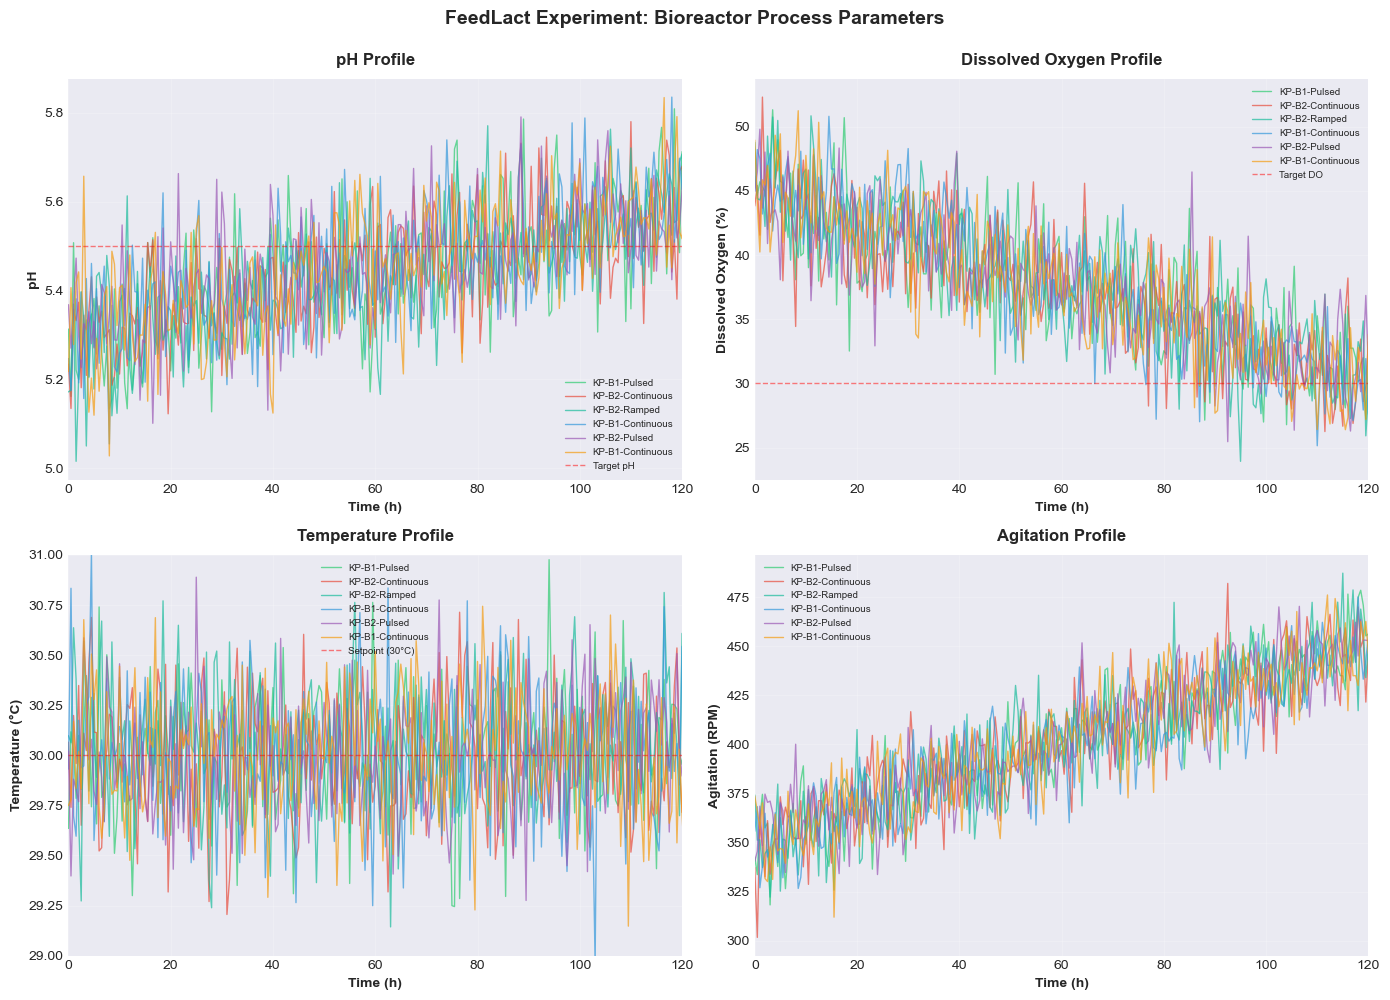

✓ Figure saved: 02_bioreactor_parameters.png

PROCESS PARAMETER STATISTICS

Overall ranges across all runs:
  pH:          5.02 - 5.84
  DO:          23.9 - 52.3%
  Temperature: 28.96 - 31.01°C
  Agitation:   302 - 487 RPM

Process control performance:
  Temperature variation (SD): ±0.30°C
  pH variation (SD): ±0.13


In [6]:
# ============================================================
# CELL 6: Bioreactor Process Parameters
# ============================================================
"""
Visualize online bioreactor sensor data (pH, DO, temperature, agitation).
High-frequency measurements collected every 30 minutes.
"""

print("\n" + "="*70)
print("BIOREACTOR PROCESS PARAMETERS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('FeedLact Experiment: Bioreactor Process Parameters', 
             fontsize=14, fontweight='bold', y=0.995)

# Define colors for runs (consistent with previous plots)
run_colors = {
    'KP_B1_run1': '#3498db',
    'KP-B1-Run-02': '#2ecc71',
    'run3_KPB1': '#f39c12',
    'KP-B2_run1': '#e74c3c',
    'KP_B2_run2': '#9b59b6',
    'KPB2-run3': '#1abc9c'
}

# Panel 1: pH Profile
ax = axes[0, 0]
for run_id in master_bioreactor['Run_ID'].unique():
    run_data = master_bioreactor[master_bioreactor['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    color = run_colors.get(run_id, '#95a5a6')
    
    # Plot with transparency
    ax.plot(run_data['Timestamp'], run_data['pH'], 
            linewidth=1, alpha=0.7, color=color,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('pH', fontweight='bold')
ax.set_title('pH Profile', fontweight='bold', pad=10)
ax.axhline(y=5.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target pH')
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 120)

# Panel 2: Dissolved Oxygen (DO)
ax = axes[0, 1]
for run_id in master_bioreactor['Run_ID'].unique():
    run_data = master_bioreactor[master_bioreactor['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    color = run_colors.get(run_id, '#95a5a6')
    
    ax.plot(run_data['Timestamp'], run_data['DO_%'], 
            linewidth=1, alpha=0.7, color=color,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Dissolved Oxygen (%)', fontweight='bold')
ax.set_title('Dissolved Oxygen Profile', fontweight='bold', pad=10)
ax.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target DO')
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 120)

# Panel 3: Temperature
ax = axes[1, 0]
for run_id in master_bioreactor['Run_ID'].unique():
    run_data = master_bioreactor[master_bioreactor['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    color = run_colors.get(run_id, '#95a5a6')
    
    ax.plot(run_data['Timestamp'], run_data['Temperature_C'], 
            linewidth=1, alpha=0.7, color=color,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Temperature (°C)', fontweight='bold')
ax.set_title('Temperature Profile', fontweight='bold', pad=10)
ax.axhline(y=30, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Setpoint (30°C)')
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 120)
ax.set_ylim(29, 31)

# Panel 4: Agitation
ax = axes[1, 1]
for run_id in master_bioreactor['Run_ID'].unique():
    run_data = master_bioreactor[master_bioreactor['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    color = run_colors.get(run_id, '#95a5a6')
    
    ax.plot(run_data['Timestamp'], run_data['Agitation_rpm'], 
            linewidth=1, alpha=0.7, color=color,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Agitation (RPM)', fontweight='bold')
ax.set_title('Agitation Profile', fontweight='bold', pad=10)
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 120)

plt.tight_layout()
plt.savefig('outputs/figures/02_bioreactor_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 02_bioreactor_parameters.png")

# Print process parameter statistics
print(f"\n{'='*70}")
print("PROCESS PARAMETER STATISTICS")
print("="*70)

print("\nOverall ranges across all runs:")
print(f"  pH:          {master_bioreactor['pH'].min():.2f} - {master_bioreactor['pH'].max():.2f}")
print(f"  DO:          {master_bioreactor['DO_%'].min():.1f} - {master_bioreactor['DO_%'].max():.1f}%")
print(f"  Temperature: {master_bioreactor['Temperature_C'].min():.2f} - {master_bioreactor['Temperature_C'].max():.2f}°C")
print(f"  Agitation:   {master_bioreactor['Agitation_rpm'].min():.0f} - {master_bioreactor['Agitation_rpm'].max():.0f} RPM")

print("\nProcess control performance:")
temp_std = master_bioreactor['Temperature_C'].std()
ph_std = master_bioreactor['pH'].std()
print(f"  Temperature variation (SD): ±{temp_std:.2f}°C")
print(f"  pH variation (SD): ±{ph_std:.2f}")


SUBSTRATE CONSUMPTION & VIABILITY


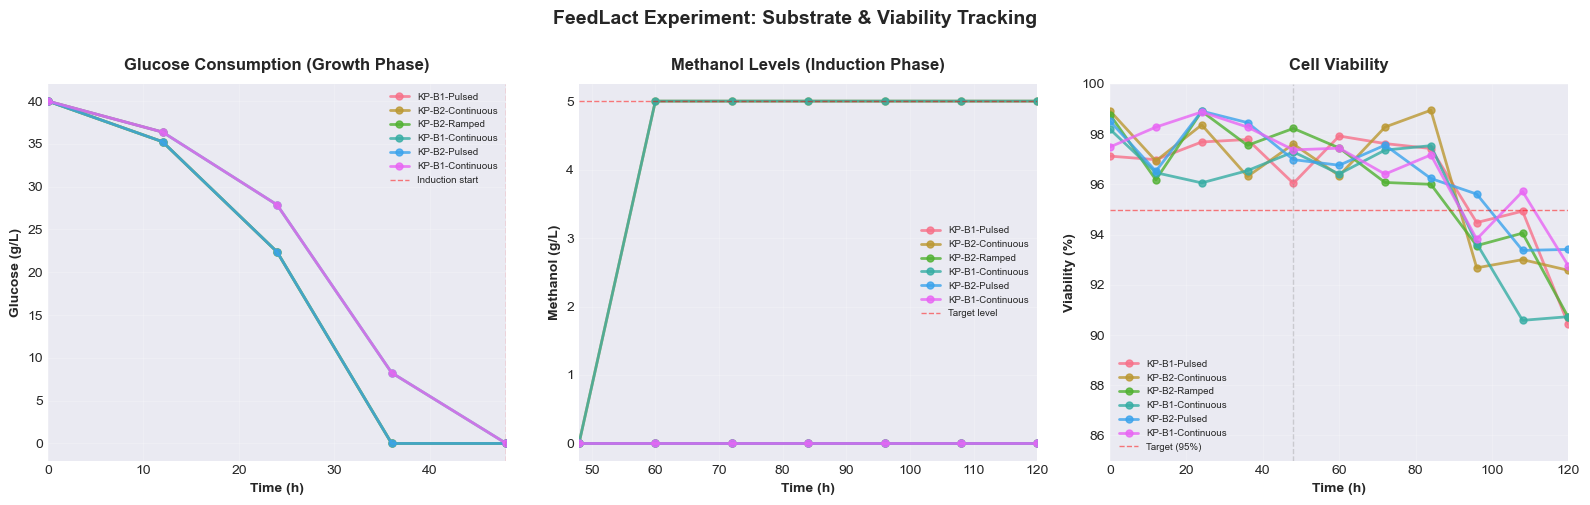

✓ Figure saved: 03_substrate_viability.png

VIABILITY STATISTICS

Average viability by condition:
                          mean   min   max  std
Strain Methanol_Strategy                       
KP-B1  Continuous         96.1  90.6  98.9  2.3
       Pulsed             96.2  90.4  97.9  2.3
KP-B2  Continuous         96.4  92.6  99.0  2.5
       Pulsed             96.6  93.4  98.9  1.9
       Ramped             96.1  90.7  98.9  2.5

Final viability (120h):
Strain  Methanol_Strategy
KP-B1   Continuous           91.7
        Pulsed               90.4
KP-B2   Continuous           92.6
        Pulsed               93.4
        Ramped               90.7
Name: Viability_%, dtype: float64


In [7]:
# ============================================================
# CELL 7: Substrate Consumption and Viability
# ============================================================
"""
Track glucose/methanol consumption and cell viability over time.
"""

print("\n" + "="*70)
print("SUBSTRATE CONSUMPTION & VIABILITY")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('FeedLact Experiment: Substrate & Viability Tracking', 
             fontsize=14, fontweight='bold', y=1.00)

# Panel 1: Glucose consumption (0-48h growth phase)
ax = axes[0]
for run_id in master_offline['Run_ID'].unique():
    run_data = master_offline[master_offline['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    
    # Filter for growth phase only
    growth_phase = run_data[run_data['Time_h'] <= 48]
    
    ax.plot(growth_phase['Time_h'], growth_phase['Glucose_gL'], 
            marker='o', linewidth=2, markersize=5, alpha=0.8,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Glucose (g/L)', fontweight='bold')
ax.set_title('Glucose Consumption (Growth Phase)', fontweight='bold', pad=10)
ax.axvline(x=48, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Induction start')
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 48)

# Panel 2: Methanol levels (48-120h induction phase)
ax = axes[1]
for run_id in master_offline['Run_ID'].unique():
    run_data = master_offline[master_offline['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    
    # Filter for induction phase only
    induction_phase = run_data[run_data['Time_h'] >= 48]
    
    ax.plot(induction_phase['Time_h'], induction_phase['Methanol_gL'], 
            marker='o', linewidth=2, markersize=5, alpha=0.8,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Methanol (g/L)', fontweight='bold')
ax.set_title('Methanol Levels (Induction Phase)', fontweight='bold', pad=10)
ax.axhline(y=5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target level')
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(48, 120)

# Panel 3: Cell viability
ax = axes[2]
for run_id in master_offline['Run_ID'].unique():
    run_data = master_offline[master_offline['Run_ID'] == run_id]
    strain = run_data['Strain'].iloc[0]
    strategy = run_data['Methanol_Strategy'].iloc[0]
    
    ax.plot(run_data['Time_h'], run_data['Viability_%'], 
            marker='o', linewidth=2, markersize=5, alpha=0.8,
            label=f"{strain}-{strategy}")

ax.set_xlabel('Time (h)', fontweight='bold')
ax.set_ylabel('Viability (%)', fontweight='bold')
ax.set_title('Cell Viability', fontweight='bold', pad=10)
ax.axhline(y=95, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Target (95%)')
ax.axvline(x=48, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax.legend(fontsize=7, loc='best', framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5)
ax.set_xlim(0, 120)
ax.set_ylim(85, 100)

plt.tight_layout()
plt.savefig('outputs/figures/03_substrate_viability.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved: 03_substrate_viability.png")

# Print viability statistics
print(f"\n{'='*70}")
print("VIABILITY STATISTICS")
print("="*70)

viability_stats = master_offline.groupby(['Strain', 'Methanol_Strategy'])['Viability_%'].agg(['mean', 'min', 'max', 'std'])
print("\nAverage viability by condition:")
print(viability_stats.round(1))

final_viability = master_offline[master_offline['Time_h'] == 120].groupby(['Strain', 'Methanol_Strategy'])['Viability_%'].mean()
print("\nFinal viability (120h):")
print(final_viability.round(1))


PERFORMANCE COMPARISON


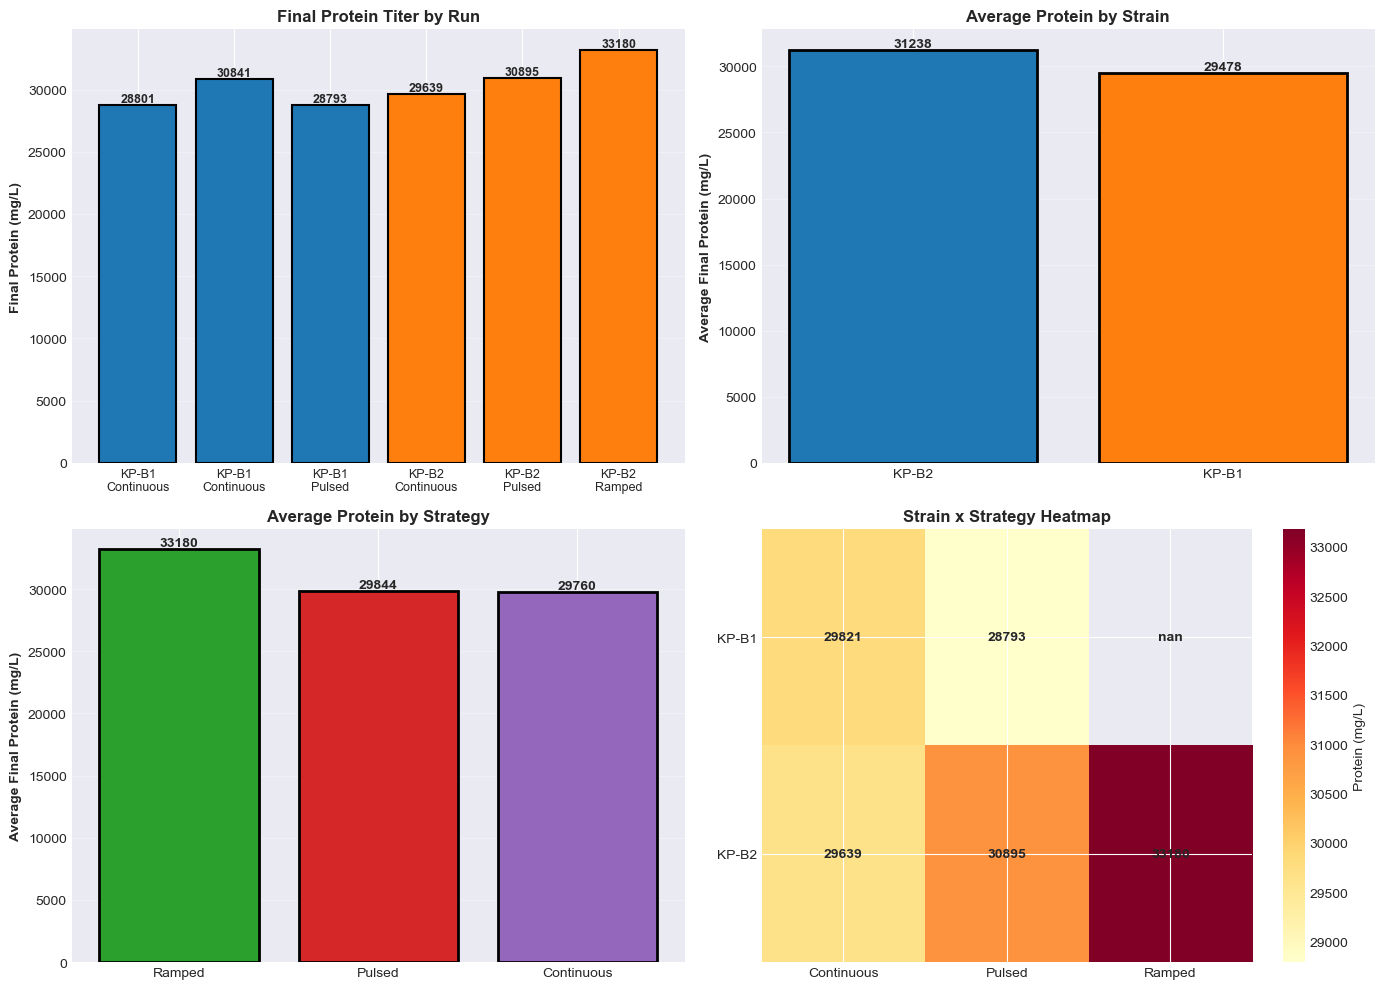

Figure saved: 04_performance_comparison.png

Performance Summary:

By Strain:
           mean     std      min      max
Strain                                   
KP-B1   29478.2  1180.1  28793.1  30840.8
KP-B2   31238.1  1795.1  29639.4  33180.0

By Strategy:
                      mean     std      min      max
Methanol_Strategy                                   
Continuous         29760.3  1025.4  28800.7  30840.8
Pulsed             29843.9  1486.1  28793.1  30894.8
Ramped             33180.0     NaN  33180.0  33180.0

Best performing run:
  KPB2-run3: KP-B2 + Ramped
  Final protein: 33180.0 mg/L


In [8]:
# ============================================================
# CELL 8: Performance Comparison
# ============================================================
print("\n" + "="*70)
print("PERFORMANCE COMPARISON")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Final protein by run
ax = axes[0, 0]
comparison = metadata.sort_values(['Strain', 'Methanol_Strategy'])
x = np.arange(len(comparison))

bars = ax.bar(x, comparison['Final_Protein_mgL'], 
              color=['#1f77b4' if s == 'KP-B1' else '#ff7f0e' for s in comparison['Strain']],
              edgecolor='black', linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([f"{row['Strain']}\n{row['Methanol_Strategy']}" 
                     for _, row in comparison.iterrows()], fontsize=9)
ax.set_ylabel('Final Protein (mg/L)', fontweight='bold')
ax.set_title('Final Protein Titer by Run', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Average by strain
ax = axes[0, 1]
avg_strain = metadata.groupby('Strain')['Final_Protein_mgL'].mean().sort_values(ascending=False)
bars = ax.bar(avg_strain.index, avg_strain.values,
              color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=2)

ax.set_ylabel('Average Final Protein (mg/L)', fontweight='bold')
ax.set_title('Average Protein by Strain', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# Panel 3: Average by strategy
ax = axes[1, 0]
avg_strategy = metadata.groupby('Methanol_Strategy')['Final_Protein_mgL'].mean().sort_values(ascending=False)
bars = ax.bar(avg_strategy.index, avg_strategy.values,
              color=['#2ca02c', '#d62728', '#9467bd'], edgecolor='black', linewidth=2)

ax.set_ylabel('Average Final Protein (mg/L)', fontweight='bold')
ax.set_title('Average Protein by Strategy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.0f}', ha='center', va='bottom', fontweight='bold')

# Panel 4: Heatmap
ax = axes[1, 1]
pivot = metadata.pivot_table(values='Final_Protein_mgL', 
                              index='Strain', columns='Methanol_Strategy')

im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)
ax.set_title('Strain x Strategy Heatmap', fontweight='bold')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        text = ax.text(j, i, f'{pivot.values[i, j]:.0f}',
                       ha='center', va='center', fontweight='bold')

plt.colorbar(im, ax=ax, label='Protein (mg/L)')

plt.tight_layout()
plt.savefig('outputs/figures/04_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 04_performance_comparison.png")

# Summary statistics
print("\nPerformance Summary:")
print("\nBy Strain:")
print(metadata.groupby('Strain')['Final_Protein_mgL'].agg(['mean', 'std', 'min', 'max']).round(1))

print("\nBy Strategy:")
print(metadata.groupby('Methanol_Strategy')['Final_Protein_mgL'].agg(['mean', 'std', 'min', 'max']).round(1))

best_run = metadata.loc[metadata['Final_Protein_mgL'].idxmax()]
print(f"\nBest performing run:")
print(f"  {best_run['Run_ID']}: {best_run['Strain']} + {best_run['Methanol_Strategy']}")
print(f"  Final protein: {best_run['Final_Protein_mgL']:.1f} mg/L")


CORRELATION ANALYSIS


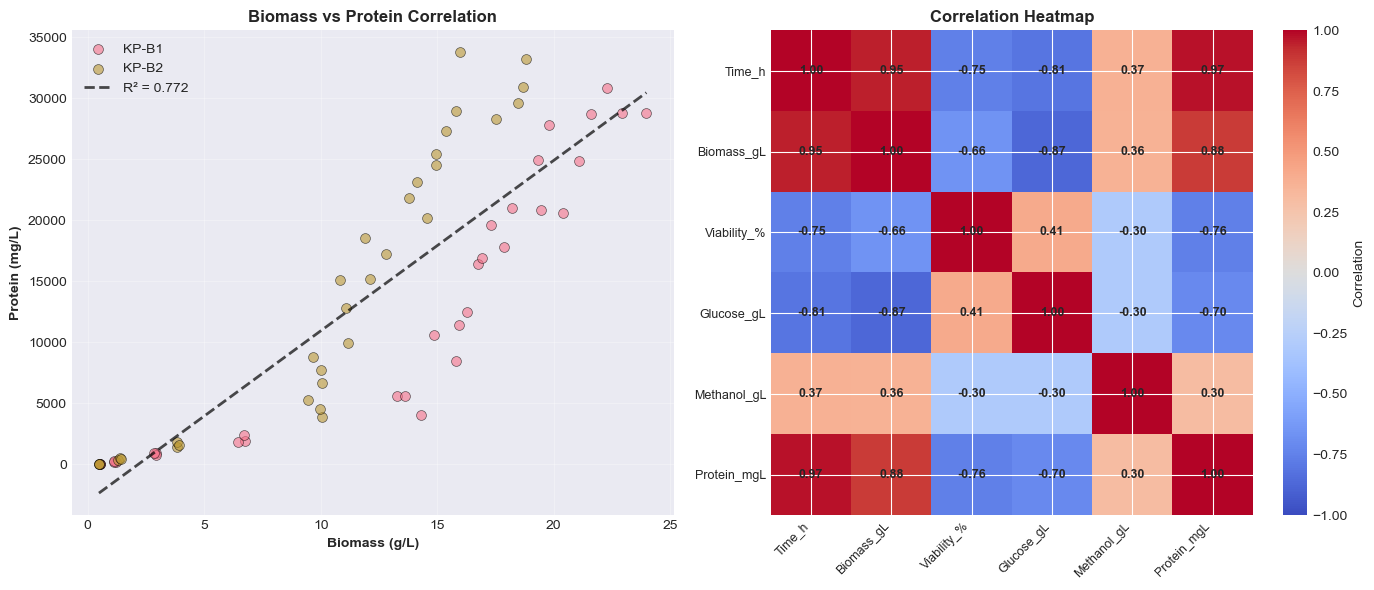

Figure saved: 05_correlation_analysis.png

Biomass-Protein correlation:
  R = 0.879
  R² = 0.772
  p-value = 3.21e-22

KEY FINDINGS

1. STRAIN COMPARISON
   Best strain: KP-B2
   Improvement: 6.0% higher than alternative

2. FEEDING STRATEGY
   Best strategy: Ramped
   Improvement: 11.5% higher than worst

3. OPTIMAL COMBINATION
   Strain: KP-B2
   Strategy: Ramped
   Final protein: 33180.0 mg/L

4. BIOMASS-PROTEIN RELATIONSHIP
   Correlation: Strong (R² = 0.772)

5. PROCESS VARIABILITY
   Coefficient of variation: 5.5%

DATA EXPLORATION AND EDA COMPLETE


In [9]:
# ============================================================
# CELL 9: Correlation Analysis and Key Findings
# ============================================================
print("\n" + "="*70)
print("CORRELATION ANALYSIS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Biomass vs Protein scatter
ax = axes[0]
for strain in master_offline['Strain'].unique():
    strain_data = master_offline[master_offline['Strain'] == strain]
    ax.scatter(strain_data['Biomass_gL'], strain_data['Protein_mgL'],
               s=50, alpha=0.6, edgecolors='black', linewidth=0.5, label=strain)

# Trend line
x = master_offline['Biomass_gL']
y = master_offline['Protein_mgL']
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
x_line = np.array([x_clean.min(), x_clean.max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'k--', linewidth=2, alpha=0.7, 
        label=f'R² = {r_value**2:.3f}')

ax.set_xlabel('Biomass (g/L)', fontweight='bold')
ax.set_ylabel('Protein (mg/L)', fontweight='bold')
ax.set_title('Biomass vs Protein Correlation', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Panel 2: Correlation heatmap
ax = axes[1]
corr_columns = ['Time_h', 'Biomass_gL', 'Viability_%', 'Glucose_gL', 'Methanol_gL', 'Protein_mgL']
corr_matrix = master_offline[corr_columns].corr()

im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr_columns)))
ax.set_yticks(np.arange(len(corr_columns)))
ax.set_xticklabels(corr_columns, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_columns, fontsize=9)
ax.set_title('Correlation Heatmap', fontweight='bold')

for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                       ha='center', va='center', fontsize=9, fontweight='bold')

plt.colorbar(im, ax=ax, label='Correlation')

plt.tight_layout()
plt.savefig('outputs/figures/05_correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: 05_correlation_analysis.png")

print(f"\nBiomass-Protein correlation:")
print(f"  R = {r_value:.3f}")
print(f"  R² = {r_value**2:.3f}")
print(f"  p-value = {p_value:.2e}")

# Key Findings
print(f"\n{'='*70}")
print("KEY FINDINGS")
print("="*70)

best_strain = metadata.groupby('Strain')['Final_Protein_mgL'].mean().idxmax()
strain_improvement = (metadata.groupby('Strain')['Final_Protein_mgL'].mean().max() / 
                      metadata.groupby('Strain')['Final_Protein_mgL'].mean().min() - 1) * 100

print(f"\n1. STRAIN COMPARISON")
print(f"   Best strain: {best_strain}")
print(f"   Improvement: {strain_improvement:.1f}% higher than alternative")

best_strategy = metadata.groupby('Methanol_Strategy')['Final_Protein_mgL'].mean().idxmax()
strategy_improvement = (metadata.groupby('Methanol_Strategy')['Final_Protein_mgL'].mean().max() / 
                        metadata.groupby('Methanol_Strategy')['Final_Protein_mgL'].mean().min() - 1) * 100

print(f"\n2. FEEDING STRATEGY")
print(f"   Best strategy: {best_strategy}")
print(f"   Improvement: {strategy_improvement:.1f}% higher than worst")

best_combo = metadata.loc[metadata['Final_Protein_mgL'].idxmax()]
print(f"\n3. OPTIMAL COMBINATION")
print(f"   Strain: {best_combo['Strain']}")
print(f"   Strategy: {best_combo['Methanol_Strategy']}")
print(f"   Final protein: {best_combo['Final_Protein_mgL']:.1f} mg/L")

correlation_desc = "Strong" if r_value**2 > 0.7 else "Moderate" if r_value**2 > 0.4 else "Weak"
print(f"\n4. BIOMASS-PROTEIN RELATIONSHIP")
print(f"   Correlation: {correlation_desc} (R² = {r_value**2:.3f})")

protein_cv = (metadata['Final_Protein_mgL'].std() / metadata['Final_Protein_mgL'].mean()) * 100
print(f"\n5. PROCESS VARIABILITY")
print(f"   Coefficient of variation: {protein_cv:.1f}%")

print(f"\n{'='*70}")
print("DATA EXPLORATION AND EDA COMPLETE")
print("="*70)